In [ ]:
def sum(a,b): 
    return a+b
sum(2,3)

5

In [2]:
E = [1,1]
B = 1
C = []
for e in E:
    C.append(e+B)
print(C)

[2, 2]


In [3]:
E = 2
B = 2
C = E + B
print(C)

4


functions and for loops

library

In [4]:
import numpy as np
import pandas as pd

def divisible_by_three(numbers):
    """Return numbers from the list that are divisible by 3."""
    return [n for n in numbers if n % 3 == 0]

# Edit this list anytime to test different inputs
numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 12]

print("Input list:", numbers)
print("Custom function result:", divisible_by_three(numbers))

# Numpy example
np_numbers = np.array(numbers)
print("NumPy result:", np_numbers[np_numbers % 3 == 0].tolist())

# Pandas example
series = pd.Series(numbers)
print("Pandas result:", series[series % 3 == 0].tolist())


Input list: [1, 2, 3, 4, 5, 6, 7, 8, 9, 12]
Custom function result: [3, 6, 9, 12]
NumPy result: [3, 6, 9, 12]
Pandas result: [3, 6, 9, 12]


In [5]:
import numpy as np
A=[3, 4]
print(np.sum(A))

7


In [6]:
# Insert a 0 after every digit in the input string
# Example: input '12345' -> output '1 0 2 0 3 0 4 0 5'

def insert_zero_between_digits(text):
    digits = list(text)
    result = []
    for i, digit in enumerate(digits):
        result.append(digit)
        if i < len(digits) - 1:
            result.append('0')
    return ' '.join(result)

input_value = '12345'
output_value = insert_zero_between_digits(input_value)
print('Input:', input_value)
print('Output:', output_value)

Input: 12345
Output: 1 0 2 0 3 0 4 0 5


Create a dummy dataset with some null values, then analyze the distribution of numeric and categorical columns.

In [7]:
import pandas as pd

# Create a dummy dataset with intentional null values
dummy_data = pd.DataFrame({
    'id': range(1, 21),
    'age': [25, 30, None, 22, 45, 34, None, 29, 40, 31, 28, None, 36, 33, 23, 41, None, 27, 39, 44],
    'score': [88, 92, 77, 85, None, 90, 73, None, 82, 95, 89, 91, None, 78, 84, 87, 93, None, 80, 86],
    'category': ['A', 'B', 'A', None, 'C', 'B', 'A', 'C', None, 'B', 'A', 'C', 'B', None, 'A', 'C', 'B', 'A', 'C', 'B'],
    'purchase_amount': [120.5, None, 85.0, 100.0, 75.5, 95.0, None, 110.0, 130.0, 120.0, 99.0, 105.5, None, 115.0, 90.0, 108.0, None, 125.0, 98.5, 132.0]
})

# Replace missing numeric values with the mean of each numeric column
numeric_means = dummy_data.select_dtypes(include=['number']).mean()
dummy_data[numeric_means.index] = dummy_data[numeric_means.index].fillna(numeric_means)

# Replace missing categorical values with the most frequent category
if 'category' in dummy_data.columns:
    most_common_category = dummy_data['category'].mode()
    if not most_common_category.empty:
        dummy_data['category'] = dummy_data['category'].fillna(most_common_category.iloc[0])

print('Dummy dataset after filling missing values:')
print(dummy_data)
print('\nNull values per column:')
print(dummy_data.isna().sum())

print('\nNumeric summary statistics:')
print(dummy_data.describe())

print('\nAll-columns summary (including categorical):')
print(dummy_data.describe(include='all'))

print('\nCategory value counts (including missing):')
print(dummy_data['category'].value_counts(dropna=False))

# Distribution analysis for numeric columns
print('\nAge distribution counts:')
print(dummy_data['age'].value_counts(dropna=False).sort_index())

print('\nScore distribution counts:')
print(dummy_data['score'].value_counts(dropna=False).sort_index())

print('\nPurchase amount distribution counts:')
print(dummy_data['purchase_amount'].value_counts(dropna=False).sort_index())

# Optional bucketed distribution for age
print('\nAge buckets:')
print(pd.cut(dummy_data['age'], bins=[20, 25, 30, 35, 40, 45, 50]).value_counts(sort=False))

Dummy dataset after filling missing values:
    id      age   score category  purchase_amount
0    1  25.0000  88.000        A         120.5000
1    2  30.0000  92.000        B         106.8125
2    3  32.9375  77.000        A          85.0000
3    4  22.0000  85.000        A         100.0000
4    5  45.0000  85.625        C          75.5000
5    6  34.0000  90.000        B          95.0000
6    7  32.9375  73.000        A         106.8125
7    8  29.0000  85.625        C         110.0000
8    9  40.0000  82.000        A         130.0000
9   10  31.0000  95.000        B         120.0000
10  11  28.0000  89.000        A          99.0000
11  12  32.9375  91.000        C         105.5000
12  13  36.0000  85.625        B         106.8125
13  14  33.0000  78.000        A         115.0000
14  15  23.0000  84.000        A          90.0000
15  16  41.0000  87.000        C         108.0000
16  17  32.9375  93.000        B         106.8125
17  18  27.0000  85.625        A         125.0000
18  19

## Dashboard: Visual analysis for the dummy dataset
Use charts to inspect distributions and relationships in the cleaned dataset.

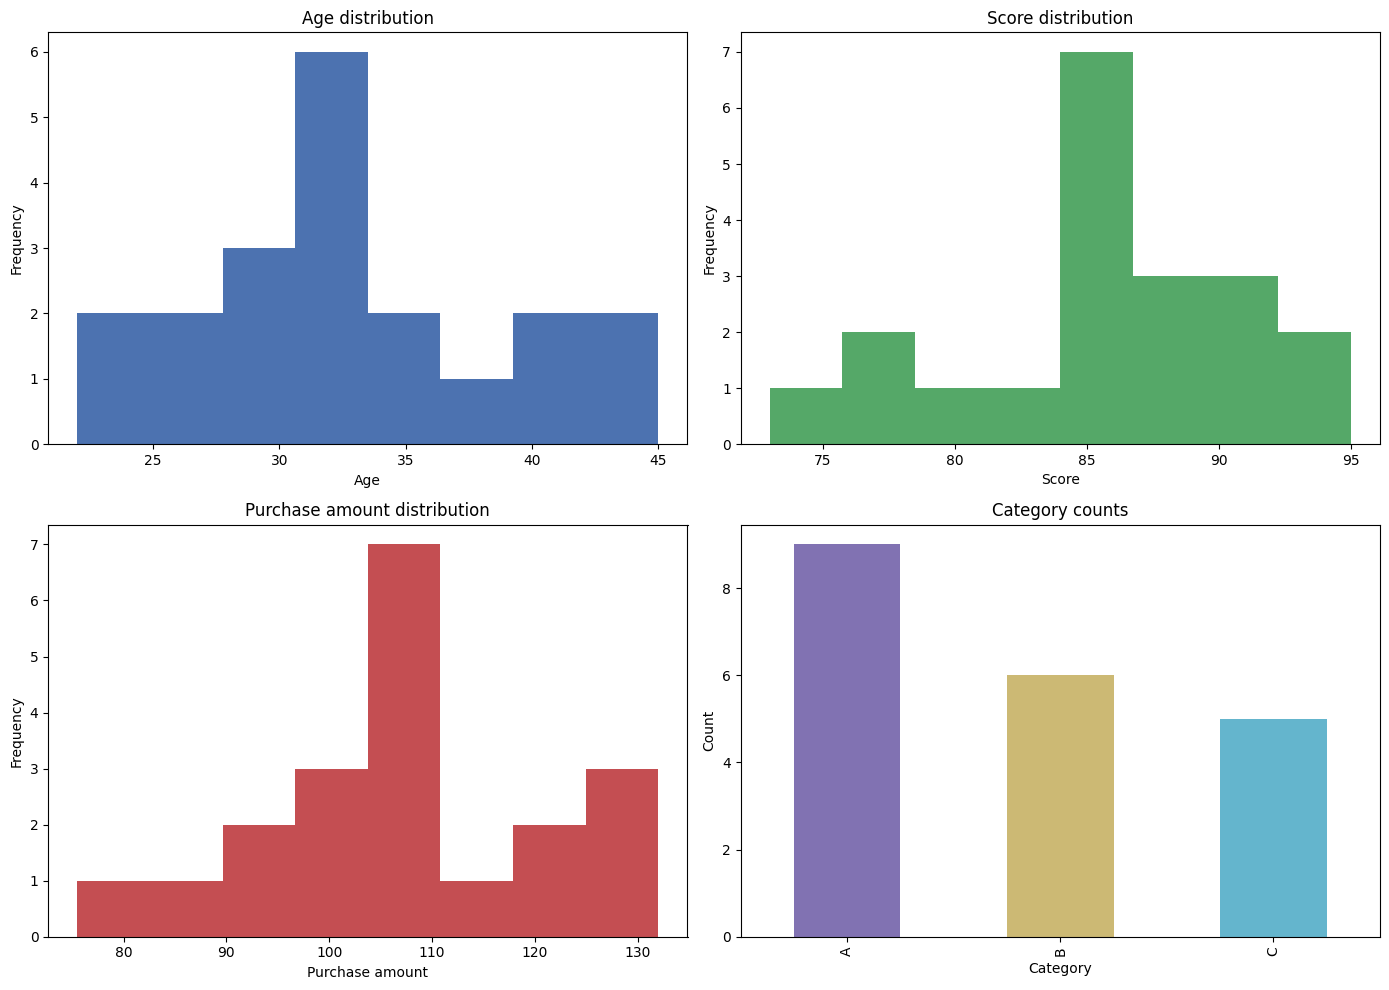

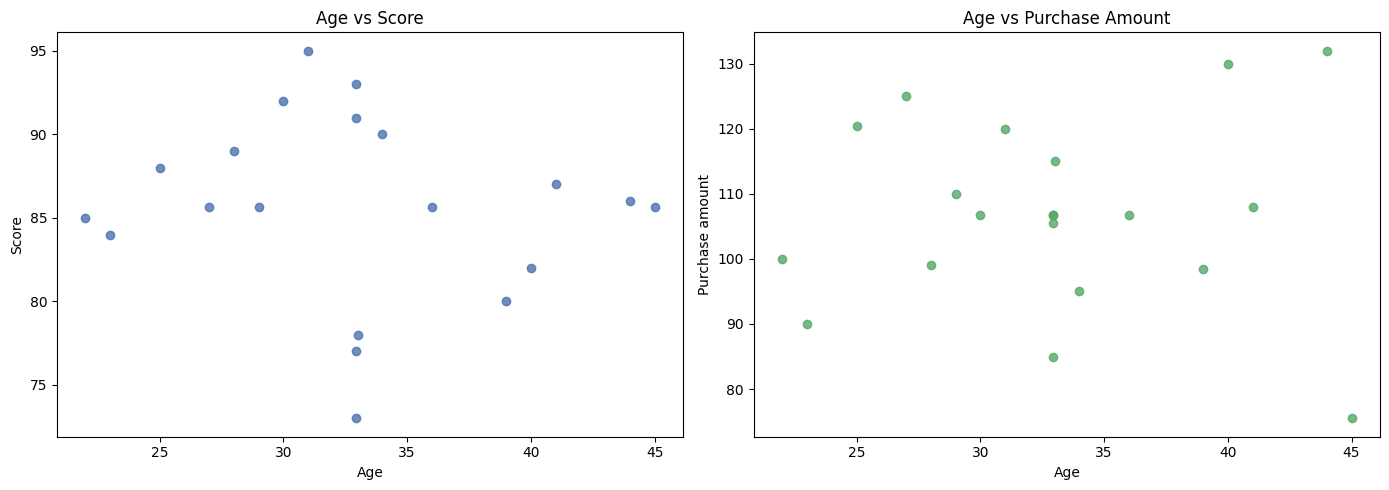

In [8]:
import matplotlib.pyplot as plt

# Dashboard plots for distributions and category counts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
dummy_data['age'].plot(kind='hist', bins=8, color='#4C72B0', ax=axes[0,0])
axes[0,0].set_title('Age distribution')
axes[0,0].set_xlabel('Age')

dummy_data['score'].plot(kind='hist', bins=8, color='#55A868', ax=axes[0,1])
axes[0,1].set_title('Score distribution')
axes[0,1].set_xlabel('Score')

dummy_data['purchase_amount'].plot(kind='hist', bins=8, color='#C44E52', ax=axes[1,0])
axes[1,0].set_title('Purchase amount distribution')
axes[1,0].set_xlabel('Purchase amount')

dummy_data['category'].value_counts().plot(kind='bar', color=['#8172B2', '#CCB974', '#64B5CD'], ax=axes[1,1])
axes[1,1].set_title('Category counts')
axes[1,1].set_xlabel('Category')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Scatter plots to show relationships
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(dummy_data['age'], dummy_data['score'], color='#4C72B0', alpha=0.8)
ax[0].set_title('Age vs Score')
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Score')

ax[1].scatter(dummy_data['age'], dummy_data['purchase_amount'], color='#55A868', alpha=0.8)
ax[1].set_title('Age vs Purchase Amount')
ax[1].set_xlabel('Age')
ax[1].set_ylabel('Purchase amount')

plt.tight_layout()
plt.show()

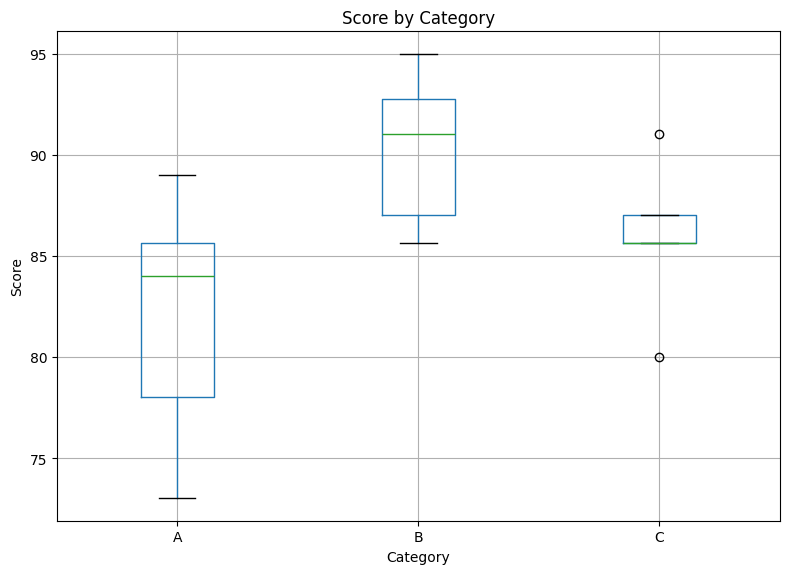

In [9]:
# Box plot: Category vs Score
fig, ax = plt.subplots(figsize=(8, 6))
dummy_data.boxplot(column='score', by='category', ax=ax)
ax.set_title('Score by Category')
ax.set_xlabel('Category')
ax.set_ylabel('Score')
plt.suptitle('')
plt.tight_layout()
plt.show()

1 replace all empty values in data set with average values
2 this data set expanded into 20 samples
3 plot and create a dashboard to analyse insights from the data set that we have